In [105]:
#load the best models from the checkpoints folder

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.utils import to_categorical 
from tensorflow.keras.models import load_model, Model
import json
import helper
import plotly.express as px

MODEL_ID = 143#35
AVERAGED = None

In [106]:
params = []
#load the json from params.json
with open('params.json') as json_file:
    params = json.load(json_file)
params = params[MODEL_ID]
print(params)
model = load_model('checkpoints/best_model_{}.h5'.format(MODEL_ID), compile=False)

{'group_size': 100, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 143}


In [107]:
#load the data
group_size = params['group_size'] if AVERAGED == None else AVERAGED
def avg(group, group_size): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res
data = pd.read_hdf("../../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
#print all the columns
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
data = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                    (data.index.get_level_values('Peptide').isin(ANTIGENS))
                ]
data = data.groupby(['Peptide', 'Time', 'Replicate', 'Concentration']).apply(avg, group_size=group_size)
antigen = list(data.index.get_level_values('Peptide'))
times = list(data.index.get_level_values('Time'))
concentration = list(data.index.get_level_values('Concentration'))
scaling_factor = 1024/(params['output_range'][1]-params['output_range'][0])
X = np.array(data.values)/scaling_factor + params['output_range'][0]
y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
y = to_categorical(y)
reconstructedX = model(X)


In [108]:
print("X shape: ", X.shape)
print("Reconstructed X shape: ", reconstructedX.shape)

X shape:  (61136, 26)
Reconstructed X shape:  (61136, 26)


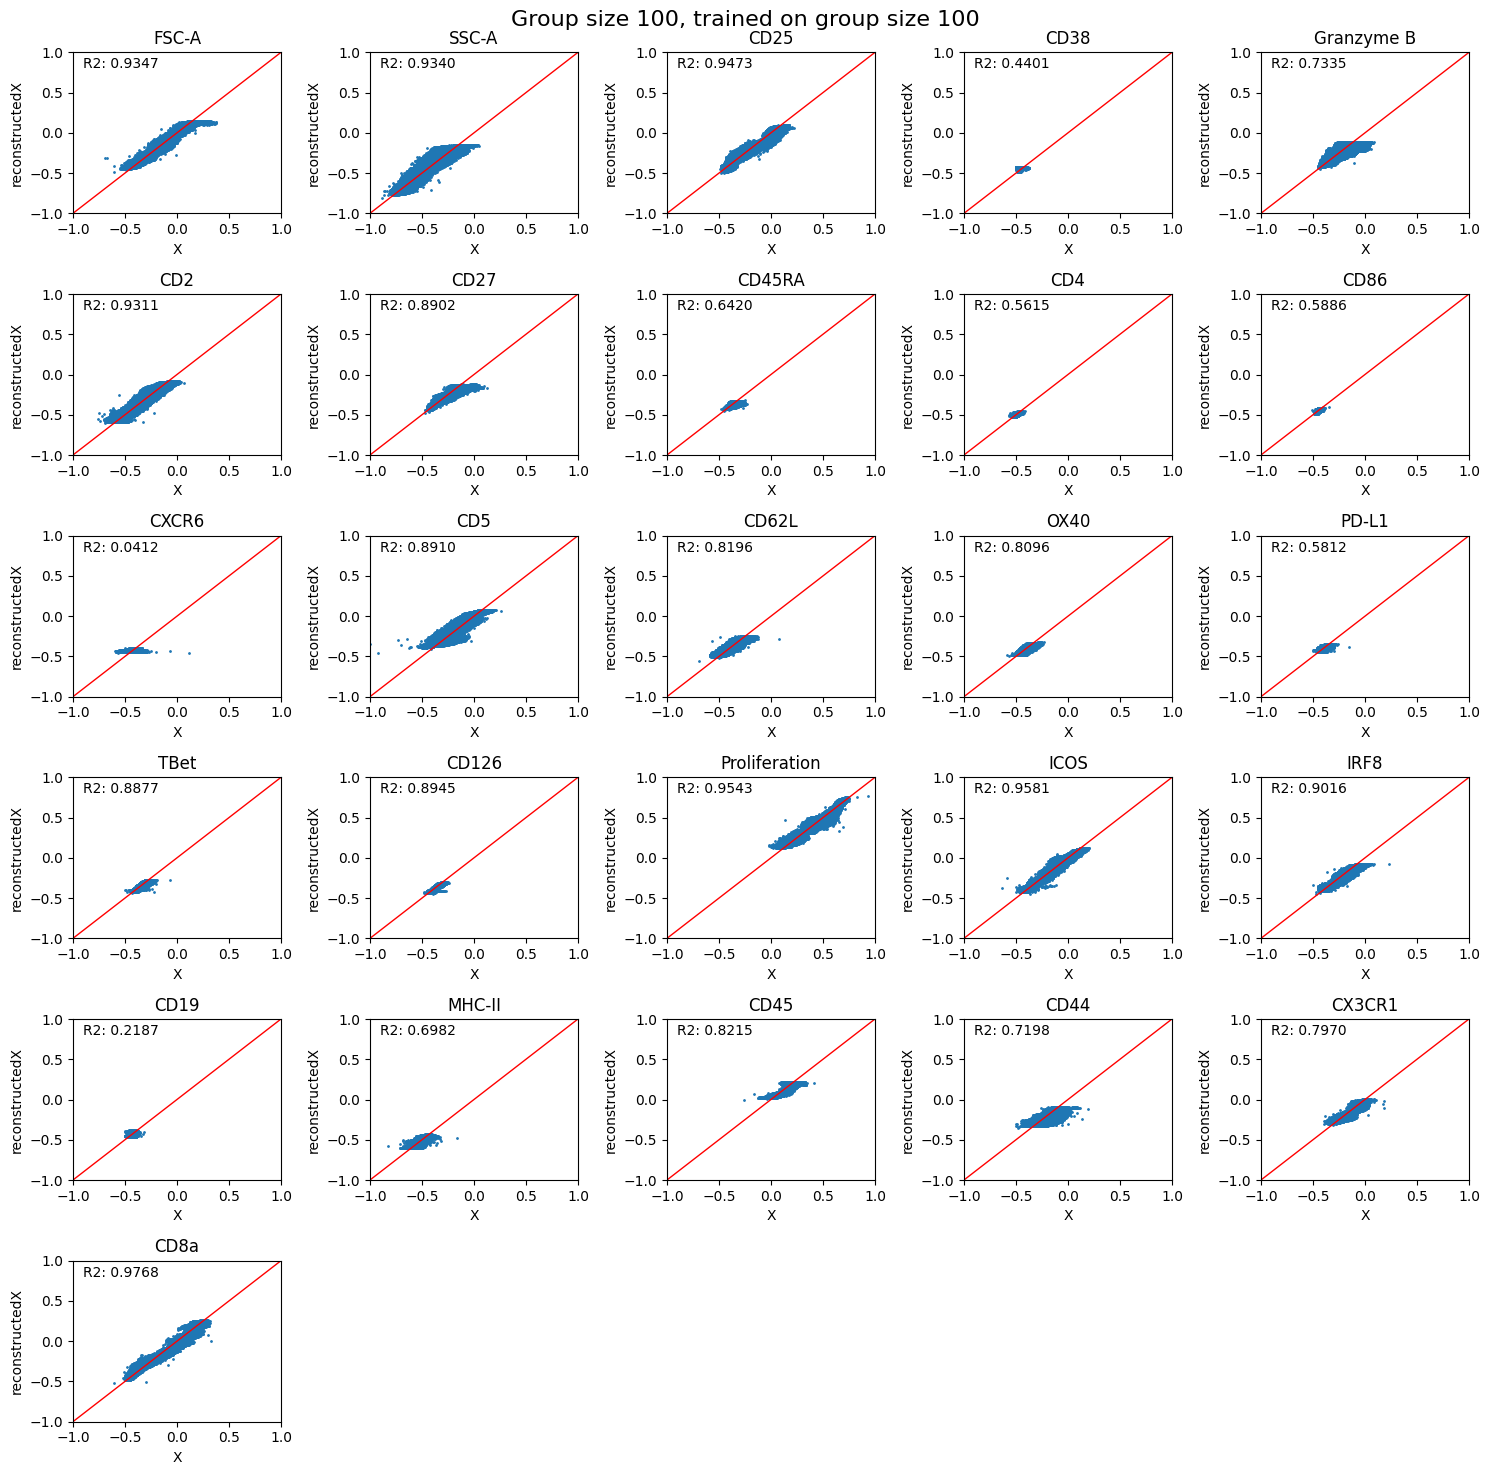

In [109]:
#plot for each of the 26 columns X vs reconstructedX
plt.figure(figsize=(15, 15))
plt.suptitle("Group size {}, trained on group size {}".format(group_size,params['group_size']), fontsize=16)
for i in range(len(data.columns)):
    plt.subplot(6, 5, i + 1)
    #scatter with opacity 0.1
    plt.scatter(X[:,i], reconstructedX[:,i], alpha=1, s=1)
    plt.title(data.columns[i])
    plt.xlabel("X")
    plt.xlim([-1, 1])
    plt.ylim([-1, 1])    
    #plot y=x
    #calculate R2 score
    r2 = np.corrcoef(X[:,i], reconstructedX[:,i])[0,1]**2
    plt.text(-0.9, 0.8, "R2: {:.4f}".format(r2))
    plt.plot([-1, 1], [-1, 1], color='red', linewidth=1)
    plt.ylabel("reconstructedX")
plt.tight_layout()
plt.show()